In [1]:
import os
from os.path import expanduser
home = expanduser("~/")

import sys
# sys.path.insert(0, '/global/u2/x/xshuang/gigalens-xh-dev/src')

# import sys
conda_env = sys.path[1]
del sys.path[1]

import os
# sys.path.append(f'{os.environ['HOME']}/gigalens_personal/gigalens/src')
sys.path.append(home+'/gigalens'+'/src')
sys.path.append(conda_env)
sys.path.append(home+'/GIGALens-Code/')
print(sys.path)

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"


srcdir = os.path.join(home, "gigalens/src/")


['', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '/usr/local/lib/python3.12/dist-packages', '__editable__.flax-0.10.6.finder.__path_hook__', '__editable__.jax_cuda12_pjrt-0.6.2.dev20250607.finder.__path_hook__', '__editable__.jax_cuda12_plugin-0.6.2.dev20250607.finder.__path_hook__', '__editable__.nsys_jax-0.1.dev1163+g4a8f06a.finder.__path_hook__', '/opt/pip/src', '/usr/lib/python3/dist-packages', '/global/homes/l/linusu//gigalens/src', '/global/homes/l/linusu/.conda/envs/gigalens_multinode_env/lib/python3.12/site-packages', '/global/homes/l/linusu//GIGALens-Code/']


In [2]:
import tensorflow_probability.substrates.jax as tfp

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear, tnfw

import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import optax
import corner
import yaml
import pickle
from helpers import *
import blackjax
import importlib
from mclmc_alt import MCLMC
tfd = tfp.distributions

In [3]:

import gigalens
importlib.reload(gigalens)
from gigalens.jax.profiles.mass import tnfw_ellipse
from gigalens.jax.profiles.light import shapelets

import lenstronomy
from lenstronomy.Data.pixel_grid import PixelGrid
import functools
from typing import List, Dict

import jax
import jax.numpy as jnp
import numpy as np
from jax import jit
from jax import lax
from lenstronomy.Util.kernel_util import subgrid_kernel
from objax.constants import ConvPadding
from objax.functional import average_pool_2d
from gigalens.jax.simulator import LensSimulator
import gigalens.model
import gigalens.simulator

In [4]:
save_dir = os.path.join(home, "GIGALens-Code/alternate_inference/dm_subhalo_complex/")

In [5]:
#* Load all outside data
import numpy as np, json
source_plane_dir = os.path.join(save_dir, "vela10_cam00_a0.500_f814w/")
# source_img_nJy = np.load(os.path.join(source_plane_dir, "source_image.npy"))
psf = np.load(os.path.join(source_plane_dir, "psf.npy"))
with open(os.path.join(source_plane_dir, "metadata.json")) as f:
    meta = json.load(f)


source_img_pixel_scale = meta['source_pixel_scale_arcsec']
delta_pix = meta['instrument_pixel_scale_arcsec']
num_pix = 200

sim_config = SimulatorConfig(delta_pix=delta_pix, num_pix=num_pix, supersample=1, kernel=psf)

observed_img = jnp.load(os.path.join(save_dir, "lens_img.npy"))

with open(os.path.join(save_dir, "true_params"), 'rb') as file_handle:
    true_params = pickle.load(file_handle)

true_squeezed = jax.tree.map(jnp.squeeze, true_params)
Rs_angle = true_squeezed[0][1]['Rs']
alpha_Rs = true_squeezed[0][1]['alpha_Rs']
halo_x = true_squeezed[0][1]['center_x']
halo_y = true_squeezed[0][1]['center_y']



background_rms = 0.002
exp_time = 2000

In [6]:
lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                theta_E=tfd.LogNormal(jnp.log(1.25), 0.4),
                gamma=tfd.TruncatedNormal(2, 0.5, 1, 3),
                e1=tfd.TruncatedNormal(0, 0.2, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.2, -0.5, 0.5),
                center_x=tfd.Normal(0, 0.2),
                center_y=tfd.Normal(0, 0.2),
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                Rs=tfd.LogNormal(jnp.log(Rs_angle), 0.3),
                alpha_Rs=tfd.LogNormal(jnp.log(alpha_Rs), 0.3),
                r_trunc=tfd.TruncatedNormal(100.0, 1.0, 90., 110.),
                e1=tfd.TruncatedNormal(0, 0.2, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.2, -0.5, 0.5),
                center_x=tfd.Normal(halo_x, 0.2),
                center_y=tfd.Normal(halo_y, 0.2),
            )
        ),
        tfd.JointDistributionNamed(
            dict(gamma1=tfd.TruncatedNormal(0, 0.1, -0.5, 0.5), gamma2=tfd.Normal(0, 0.1, -0.5, 0.5))
        ),
    ]
)
lens_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.6), 0.25),
                n_sersic=tfd.Uniform(0.5, 8),
                e1=tfd.TruncatedNormal(0, 0.1, -0.2, 0.2),
                e2=tfd.TruncatedNormal(0, 0.1, -0.2, 0.2),
                center_x=tfd.Normal(0, 0.2),
                center_y=tfd.Normal(0, 0.2),
                # Ie=tfd.LogNormal(jnp.log(300.0), 0.5),
            )
        )
    ]
)

n_max = 10
# amp_prior = {key: tfd.Normal(0,500/float(jnp.sqrt(i+1))) for i, key in enumerate(shapelets.Shapelets(n_max)._amp_names)}


source_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                beta=tfd.LogNormal(jnp.log(0.7), 0.4),
                center_x=tfd.Normal(0, 0.01),
                center_y=tfd.Normal(0, 0.01),
                # **amp_prior
            )
        ),
    ]
)


prior_with_halo = tfd.JointDistributionSequential(
    [lens_prior, lens_light_prior, source_light_prior]
)

phys_model_halo = PhysicalModel([epl.EPL(50), tnfw_ellipse.TNFW_Ellipse(), shear.Shear()], [sersic.SersicEllipse(use_lstsq=True)], [shapelets.Shapelets(n_max=n_max, use_lstsq=True, interpolate=True)])
lens_sim_halo = LensSimulator(phys_model_halo, sim_config, bs=1)
    
prob_model_halo = BackwardProbModel(prior_with_halo, observed_img, background_rms=background_rms, exp_time=exp_time)
model_seq_halo = ModellingSequence(phys_model_halo, prob_model_halo, sim_config)

In [ ]:
pipelinecfg = PipelineConfig(steps=["MAP", "SVI"],map_kwargs={"num_steps":350, "n_samples":500}, )
results_halo = run_pipeline(model_seq_halo, pipelinecfg)

Starting MAP


  0%|          | 0/350 [00:20<?, ?it/s]

In [ ]:
# qz = results_halo["SVI"].qz
# best = results_halo["MAP"].best_z

# jnp.save(os.path.join(save_dir, "best_halo.npy"), best)
# jnp.savez(os.path.join(save_dir, 'qz_halo.npz'), loc=qz.loc, scale_tril=qz.scale_tril)

best_halo = jnp.load(os.path.join(save_dir, "best_halo.npy"))

f = jnp.load(os.path.join(save_dir, 'qz_halo.npz'))
qz_halo = tfd.MultivariateNormalTriL(loc=f['loc'], scale_tril=f['scale_tril'])

# default_start = jnp.diag(jnp.ones((best_halo.shape[-1],))) * 1e-3
# no_SVI_qz = tfd.MultivariateNormalTriL(loc=jnp.squeeze(best_halo), scale_tril=default_start)
# qz_halo=no_SVI_qz
# results_halo["SVI"].qz = no_SVI_qz

# qz_halo = results_halo["SVI"].qz

In [14]:
import mclmc_alt
importlib.reload(mclmc_alt)
from mclmc_alt import MCLMC_JIT

num_burnin_steps = 1000
num_results=1000
frac_tune1=0.2 #* initial step size tuning
frac_tune2=0.6 #* Used for mass matrix adaptation
frac_tune3=0.2 #! Tuning L. ~10 effective samples are needed for this to be accurate

debug_hist = MCLMC_JIT(
    model_seq_halo, qz_halo, 
    n_hmc=16, num_burnin_steps=num_burnin_steps, num_results=num_results, 
    desired_energy_variance=5e-4, frac_tune1=frac_tune1, frac_tune2=frac_tune2, frac_tune3=frac_tune3,
    seed=0, debug_output=True, step_size_adapt_use_psmile=True, use_shard_map=True,
) # previous time: 124s

Sampling took 116.88324565000948 s


In [15]:
mclmc_samples = debug_hist.position[:, -num_results:, :]

jnp.save(os.path.join(save_dir, "mclmc_samples_halo_model"), mclmc_samples)

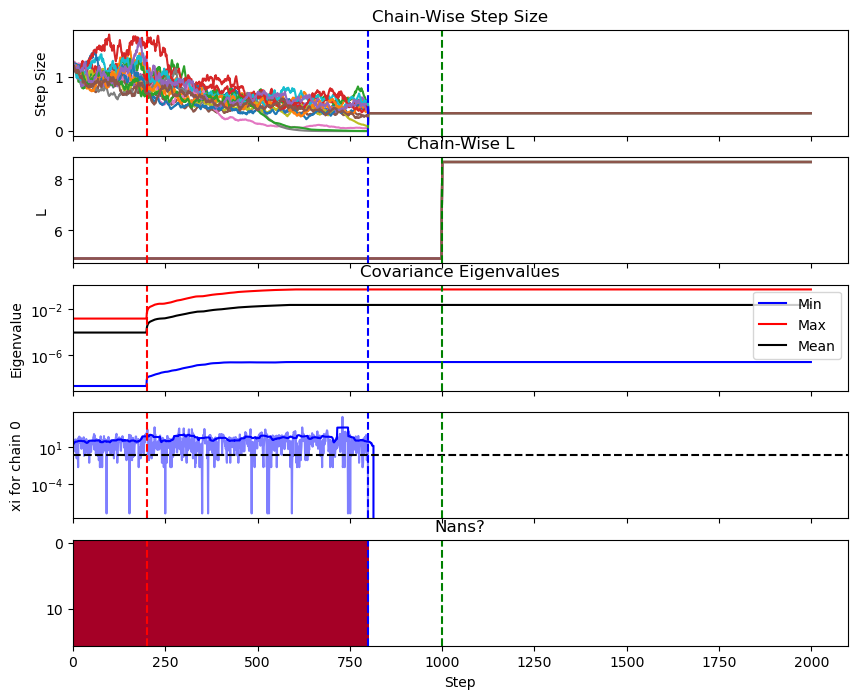

In [16]:
stage1 = int(frac_tune1*num_burnin_steps)
stage2 = int((frac_tune1+frac_tune2)*num_burnin_steps)
stage3 = int((frac_tune1+frac_tune2+frac_tune3)*num_burnin_steps)

fig, axs = plt.subplots(5, 1, sharex=True)
ax1, ax2, ax3, ax4, ax_last =axs
fig.set_size_inches(10, 8)
ax1.plot(debug_hist.step_size.T)
ax1.set_title("Chain-Wise Step Size")
ax1.set_ylabel("Step Size")
# ax1.set_ylim(top=10)
# ax1.set_yscale('log')

ax2.plot(debug_hist.L.T)
ax2.set_title("Chain-Wise L")
ax2.set_ylabel("L")
# ax2.set_ylim(top=20)



inverse_mass_matrix_hist = debug_hist.inverse_mass_matrix[0]
vmapped_eigval = jax.vmap(lambda x: jnp.linalg.eig(x)[0])
mass_mat_eigval = vmapped_eigval(inverse_mass_matrix_hist)
min_eigval = jnp.min(mass_mat_eigval, axis=1)
max_eigval = jnp.max(mass_mat_eigval, axis=1)
mean_eigval = jnp.mean(mass_mat_eigval, axis=1)

ax3.plot(min_eigval, label='Min', color='blue')
ax3.plot(max_eigval, label='Max', color='red')
ax3.plot(mean_eigval, label='Mean', color='black')
ax3.legend()
ax3.set_title("Covariance Eigenvalues")
ax3.set_yscale('log')
ax3.set_ylabel("Eigenvalue")



smooth_kernel_size = 30
kernel = np.ones(smooth_kernel_size) / smooth_kernel_size
xi_chain = debug_hist.xi[8]
xi_smoothed = np.convolve(xi_chain, kernel, mode='same')
ax4.plot(xi_chain, alpha=0.5, color='blue')
ax4.plot(xi_smoothed, alpha=1.0, color='blue')
ax4.set_yscale('log')
ax4.set_ylabel("xi for chain 0")
ax4.axhline(1.0, color='black', linestyle='--')

ax_last.set_xlabel("Step")

ax_last.set_title("Nans?")
ax_last.imshow(debug_hist.nonan[:,:stage2], aspect='auto', interpolation='none', cmap='RdYlGn')

for ax in axs:
    ax.axvline(stage1, color='red', linestyle='--')
    ax.axvline(stage2, color='blue', linestyle='--')
    ax.axvline(stage3, color='green', linestyle='--')

    # ax.set_xlim(right=stage3)


plt.show()

In [ ]:
print(jnp.max(blackjax.diagnostics.potential_scale_reduction(mclmc_samples, chain_axis=0, sample_axis=1)))
print(blackjax.diagnostics.effective_sample_size(mclmc_samples, chain_axis=0, sample_axis=1))
dim=mclmc_samples.shape[-1]
run_key = jax.random.key(0)
samples = mclmc_samples[:, :,:].reshape(-1, dim) #samples_mclmc 
MCMC_x = prob_model_halo.bij.forward(list(samples.T))

adapt_cov = debug_hist.inverse_mass_matrix[0, -1]
adapt_qz = tfd.MultivariateNormalFullCovariance(loc=jnp.mean(samples, axis=0), covariance_matrix=adapt_cov)
adapt_qz_samples = adapt_qz.sample((10000,), run_key)
adapt_qz_x = prob_model_halo.bij.forward(list(adapt_qz_samples.T))

SVI_samples = qz_halo.sample((1000,), run_key)
SVI_x = prob_model_halo.bij.forward(list(SVI_samples.T))

MAP_x = prob_model_halo.bij.forward(list(best_halo.T))

# HMC_1chain_x = prob_model.bij.forward(list(results['HMC'].HMC_samples_z[0, 11, -40000:].T))

plot_params = cornerplot_labels(MCMC_x)[:21]

# hmc_x = prob_model.bij.forward(list(hmc_samples.reshape(-1, dim).T))

# n_samp = hmc_samples.shape[0]*hmc_samples.shape[1]
# rand_idx = np.random.choice(np.arange(n_samp), size=(10000,), replace=False)

# fig = cornerplot_posterior(jax.tree.map(lambda x: x[rand_idx], hmc_x), color='black',plot_params=plot_params)

n_samp_MCMC = MCMC_x[0][0]['e1'].shape[0]
rand_idx_MCMC = np.random.choice(np.arange(n_samp_MCMC), size=(20000,), replace=True)
fig = cornerplot_posterior(jax.tree.map(lambda x: x[rand_idx_MCMC], MCMC_x), color='black',plot_params=plot_params)


# cornerplot_posterior(SVI_x, fig=fig, color='blue', plot_params=plot_params, overplots=MAP_x, truth=true_params)
cornerplot_posterior(adapt_qz_x, fig=fig, color='purple', plot_params=plot_params,overplots=MAP_x, truth=true_params)
# cornerplot_posterior(mclmc_results_100sys.HMC_samples, fig=fig, color='purple', plot_params=plot_params)
# cornerplot_posterior(HMC_1chain_x, fig=fig, color='green', plot_params=plot_params)

plt.show()

In [19]:
ess = blackjax.diagnostics.effective_sample_size(mclmc_samples, chain_axis=0, sample_axis=1)
rhat = blackjax.diagnostics.potential_scale_reduction(mclmc_samples, chain_axis=0, sample_axis=1)
struct = jax.tree.structure(MAP_x)
jax.tree.unflatten(struct, rhat)
# jnp.sort(rhat)

[[{'center_x': Array(1.0142871, dtype=float32),
   'center_y': Array(1.0168507, dtype=float32),
   'e1': Array(1.0814121, dtype=float32),
   'e2': Array(1.0252, dtype=float32),
   'gamma': Array(1.0773413, dtype=float32),
   'theta_E': Array(1.0312883, dtype=float32)},
  {'Rs': Array(1.0174083, dtype=float32),
   'alpha_Rs': Array(1.0496756, dtype=float32),
   'center_x': Array(1.0159646, dtype=float32),
   'center_y': Array(1.0180041, dtype=float32),
   'e1': Array(1.4130993, dtype=float32),
   'e2': Array(1.0194879, dtype=float32),
   'r_trunc': Array(1.0345851, dtype=float32)},
  {'gamma1': Array(1.0605855, dtype=float32),
   'gamma2': Array(1.0258547, dtype=float32)}],
 [{'R_sersic': Array(1.0067503, dtype=float32),
   'center_x': Array(1.0137908, dtype=float32),
   'center_y': Array(1.0098729, dtype=float32),
   'e1': Array(1.0076059, dtype=float32),
   'e2': Array(1.0287488, dtype=float32),
   'n_sersic': Array(1.0133959, dtype=float32)}],
 [{'beta': Array(1.0861795, dtype=float3

In [39]:
lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                theta_E=tfd.LogNormal(jnp.log(1.25), 0.4),
                gamma=tfd.TruncatedNormal(2, 0.5, 1, 3),
                e1=tfd.TruncatedNormal(0, 0.2, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.2, -0.5, 0.5),
                center_x=tfd.Normal(0, 0.2),
                center_y=tfd.Normal(0, 0.2),
            )
        ),
        tfd.JointDistributionNamed(
            dict(gamma1=tfd.TruncatedNormal(0, 0.1, -0.5, 0.5), gamma2=tfd.Normal(0, 0.1, -0.5, 0.5))
        ),
    ]
)
lens_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.6), 0.25),
                n_sersic=tfd.Uniform(0.5, 8),
                e1=tfd.TruncatedNormal(0, 0.1, -0.2, 0.2),
                e2=tfd.TruncatedNormal(0, 0.1, -0.2, 0.2),
                center_x=tfd.Normal(0, 0.2),
                center_y=tfd.Normal(0, 0.2),
                # Ie=tfd.LogNormal(jnp.log(300.0), 0.5),
            )
        )
    ]
)

# amp_prior = {key: tfd.Normal(0,500/float(jnp.sqrt(i+1))) for i, key in enumerate(shapelets.Shapelets(n_max)._amp_names)}


source_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                beta=tfd.LogNormal(jnp.log(0.7), 0.4),
                center_x=tfd.Normal(0, 0.01),
                center_y=tfd.Normal(0, 0.01),
            )
        ),
    ]
)


prior_no_halo = tfd.JointDistributionSequential(
    [lens_prior, lens_light_prior, source_light_prior]
)

# observed_img = np.load(gigal_dir + '/assets/demo.npy')
phys_model_no_halo = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=True)], [shapelets.Shapelets(n_max=n_max, use_lstsq=True, interpolate=True)])
lens_sim_no_halo = LensSimulator(phys_model_no_halo, sim_config, bs=1)

observed_img = jnp.load(os.path.join(save_dir, "lens_img.npy"))
prob_model_no_halo = ForwardProbModel(prior_no_halo, observed_img, background_rms=background_rms, exp_time=exp_time)
model_seq_no_halo = ModellingSequence(phys_model_no_halo, prob_model_no_halo, sim_config)

In [40]:
pipelinecfg = PipelineConfig(steps=["MAP", "SVI"],map_kwargs={"num_steps":1000, "n_samples":1000}, )
results_no_halo = run_pipeline(model_seq_no_halo, pipelinecfg)

Starting MAP


Chi-squared: 1.455: 100%|██████████| 1000/1000 [01:46<00:00,  9.40it/s]


Final Chi-squared: 1.45407
Starting SVI


2026-03-06 17:16:56.572808: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
-ELBO: -162313.391: 100%|██████████| 500/500 [00:22<00:00, 22.41it/s]


In [41]:
num_burnin_steps = 1000
num_results=1000
frac_tune1=0.2 #* initial step size tuning
frac_tune2=0.6 #* Used for mass matrix adaptation
frac_tune3=0.2 #! Tuning L. ~10 effective samples are needed for this to be accurate

debug_hist = MCLMC_JIT(
    model_seq_no_halo, qz_no_halo, 
    n_hmc=16, num_burnin_steps=num_burnin_steps, num_results=num_results, 
    desired_energy_variance=5e-4, frac_tune1=frac_tune1, frac_tune2=frac_tune2, frac_tune3=frac_tune3,
    seed=0, debug_output=True, step_size_adapt_use_psmile=True,
)

mclmc_samples = debug_hist.position[:, -num_results, :]

jnp.save(os.path.join(save_dir, "mclmc_samples_no_halo_model"), mclmc_samples)

Sampling took 110.0634642210207 s


In [44]:
# results = {}
# results["MAP"] = MAPResults.load(os.path.join(home, "GIGALens-Code/alternate_inference/test_system"), model_seq)
# results["SVI"] = SVIResults.load(os.path.join(home, "GIGALens-Code/alternate_inference/test_system"), model_seq)
# results["HMC"] = HMCResults.load(os.path.join(home, "GIGALens-Code/alternate_inference/test_system"), model_seq)
# best = results["MAP"].best_z
# qz = results["SVI"].qz
# hmc_smp = jnp.transpose(results["HMC"].HMC_samples_z, (1, 2, 0, 3)).reshape((48, 750, 22))
mclmc_samples_no_halo = jnp.load(os.path.join(save_dir, "mclmc_samples_no_halo.npy"))
mclmc_samples_halo = jnp.load(os.path.join(save_dir, "mclmc_samples_halo_model.npy"))
print(jnp.max(blackjax.diagnostics.potential_scale_reduction(mclmc_samples_no_halo, chain_axis=0, sample_axis=1)))
print(jnp.max(blackjax.diagnostics.potential_scale_reduction(mclmc_samples_halo, chain_axis=0, sample_axis=1)))

1.0628097
1.000337


In [46]:
importlib.reload(helpers)
from helpers import *

In [47]:

def bridge_sampler(rng_key, samples, log_posterior_fn, n_iter=500):
    """
    Estimates the log-marginal likelihood using the Meng-Wong bridge sampler.
    
    Args:
        rng_key: JAX random key.
        samples: MCMC samples of shape (n_samples, n_dim).
        log_posterior_fn: Function mapping (theta) -> log_posterior(theta).
        n_iter: Number of iterations for the Meng-Wong algorithm.
    """
    n_samples, n_dim = samples.shape
    
    # 1. Fit a Gaussian proposal to the MCMC samples
    mu = jnp.mean(samples, axis=0)
    cov = jnp.cov(samples, rowvar=False)
    proposal = tfd.MultivariateNormalFullCovariance(loc=mu, covariance_matrix=cov)
    
    # 2. Draw 'fake' samples from the proposal
    prop_key, _ = jax.random.split(rng_key)
    gen_samples = proposal.sample(n_samples, seed=prop_key)
    
    l1 = log_posterior_fn(samples)
    l2 = log_posterior_fn(gen_samples)
    
    
    q1 = proposal.log_prob(samples)
    q2 = proposal.log_prob(gen_samples)

    n_lp_dims = len(l1.shape)-1
    if n_lp_dims > 0:
        q1 = jnp.expand_dims(q1, axis=tuple(range(-n_lp_dims, 0)))
        q2 = jnp.expand_dims(q2, axis=tuple(range(-n_lp_dims, 0)))
    
    # 4. Iterative Meng-Wong Algorithm
    log_r_guess = jnp.log(1/n_samples) + jax.nn.logsumexp(l2-q2, axis=0)
    log_r = log_r_guess

    
    h = []
    s1 = 0.5 # Proportion of samples from posterior (assuming n1 == n2)
    s2 = 0.5 # Proportion of samples from proposal
    
    for _ in range(n_iter):
        l_num = l2 - jnp.logaddexp(jnp.log(s1) + l2, jnp.log(s2) + log_r + q2)
        
        l_den = q1 - jnp.logaddexp(jnp.log(s1) + l1, jnp.log(s2) + log_r + q1)
        
        # Update log_r
        log_r_new = jax.nn.logsumexp(l_num, axis=0) - jax.nn.logsumexp(l_den, axis=0)
        
        # For stability, we can track the delta or use a small dampening factor if needed
        log_r = log_r_new
        h.append(log_r)

    return log_r, jnp.stack(h)

def evidence_and_map(samples, prob_model, lens_sim):
    # log_prob_image_vmap = jax.vmap(lambda z : log_prob_image_patched(prob_model, lens_sim, z, kernel_size=1), in_axes=0)
    
    smp = samples.reshape((-1, samples.shape[-1]))
    idxes = jax.random.choice(jax.random.key(2), smp.shape[0], shape=(2000,))

    # log_r_img, h = bridge_sampler(jax.random.key(0), smp[idxes], log_prob_image_vmap)

    def log_prob(z):
        return prob_model.log_prob(lens_sim, z)[0]

    log_r,h = bridge_sampler(jax.random.key(1), smp[idxes], log_prob)

    return log_r, None

In [48]:
z_halo, z_map_halo = evidence_and_map(mclmc_samples_halo, prob_model_halo, lens_sim_halo)
z_no_halo, z_map_no_halo = evidence_and_map(mclmc_samples_no_halo, prob_model_no_halo, lens_sim_no_halo)


2026-03-06 17:25:43.176484: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-06 17:25:48.250662: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng35{k2=4,k3=0} for conv %cudnn-conv-bias-activation = (f32[2000,1,200,200]{3,2,1,0}, u8[0]{0}) custom-call(%bitcast.36, %constant.234, %constant.3332), window={size=25x25 pad=12_12x12_12}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_name="jit(log_prob)/jit(main)/jit(simulate)/conv_general_dilated" source_file="/global/homes/l/linusu//gigalens/src/gigalens/jax/simulator.py" source_line=80}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":0.00089999998454004

In [49]:
print(f"Halo Model Z:, {z_halo:.2f}. No-Halo Model Z: {z_no_halo:.2f}")
print(f"Halo is {jnp.exp(z_halo-z_no_halo):.2f}x (10^{(z_halo-z_no_halo)/jnp.log(10):.1f}) as likely")

Halo Model Z:, 163795.19. No-Halo Model Z: 162547.53
Halo is infx (10^541.9) as likely


In [50]:
import matplotlib

TypeError: Image data of dtype object cannot be converted to float

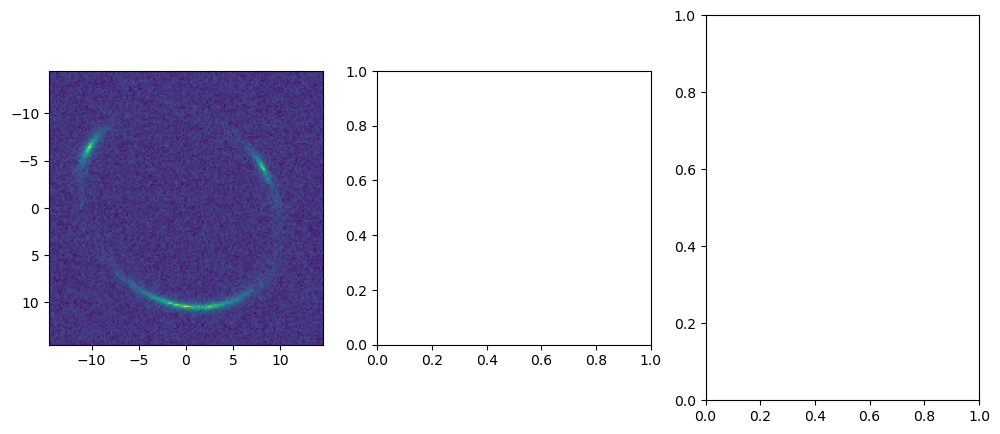

In [118]:
fig, (ax0, ax1,ax2) = plt.subplots(1,3)
fig.set_size_inches(12, 5)
extent = [-dim/2, dim/2, dim/2, -dim/2,]

halo_median = jnp.median(mclmc_samples_halo, axis=(0,1))
med_x = prob_model_halo.bij.forward(list(halo_median.T))
halox_pred, haloy_pred = med_x[0][1]['center_x'], med_x[0][1]['center_y']



ax0.imshow(observed_img, extent=extent)

# cnorm = matplotlib.colors.Normalize(vmin=min(jnp.min(z_map_halo), jnp.min(z_map_no_halo)), vmax=max(jnp.max(z_map_halo), jnp.max(z_map_no_halo)))
tr = lambda x : x#jnp.square(x-jnp.min(x))
im1 = ax1.imshow(tr(z_map_halo), extent=extent, cmap='plasma')#, norm=cnorm)
ax1.set_title("Halo Model Evidence Map")
# ax1.plot(halox_pred, haloy_pred, "g^", label="Pred Halo Location", markersize=3)
# ax1.plot(halo_x, halo_y, "k^", label="True Halo Location", markersize=3)
# ax1.legend()

im2 = ax2.imshow(tr(z_map_no_halo), extent=extent, cmap='plasma')#, norm=cnorm)
ax2.set_title("No-Halo Model Evidence Map")
# ax2.plot(halo_x, halo_y, "k^", label="True Halo Location", markersize=3)
# ax2.legend()

for ax in (ax0, ax1, ax2):
    ax.set_xlim((extent[0], extent[1]))
    ax.set_ylim((extent[2], extent[3]))

for ax, im in zip((ax1, ax2), (im1, im2)):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im, cax=cax)
    
plt.show()

1.6360398908022806


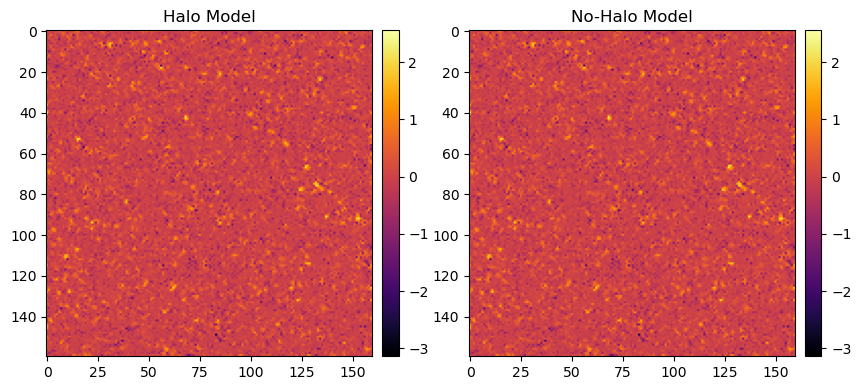

In [121]:
from scipy.ndimage import gaussian_filter, convolve

def compute_local_morans_i(residual_image):
    """
    Computes the Local Moran's I map for a 2D residual image.
    
    Positive values indicate clusters of similar values (correlated misfit).
    Negative values indicate spatial outliers.
    Values near zero indicate randomness (pure noise).
    """
    # 1. Standardize the image (z-scores)
    # If your residual is already perfectly N(0,1), this step is just a safeguard
    # z = (residual_image - np.mean(residual_image)) / np.std(residual_image)
    z = residual_image
    
    # 2. Define the spatial weights matrix (Moore neighborhood / 8-connected)
    # The center is 0 because a pixel shouldn't be correlated with itself
    # We divide by 8 to row-standardize the weights
    kernel = np.array([[1, 1, 1],
                       [1, 0, 1],
                       [1, 1, 1]]) / 8.0

    # kernel = np.array([[0.5, 0.5, 0.5, 0.5, 0.5],
    #                    [0.5, 1, 1, 1, 0.5],
    #                    [0.5, 1, 0, 1, 0.5],
    #                    [0.5, 1, 1, 1, 0.5],
    #                    [0.5, 0.5, 0.5, 0.5, 0.5]])
    # kernel /= np.sum(kernel)

    # kernel = np.ones(shape=(5,5))
    # kernel[2,2]=0
    # kernel /= np.sum(kernel)

    
    # 3. Compute the spatial lag (weighted average of neighbors)
    # mode='reflect' handles the edges nicely
    z_lag = convolve(z, kernel, mode='reflect')
    
    # 4. Calculate Local Moran's I
    local_morans_i = z * z_lag
    
    return local_morans_i

halo_median = jnp.median(mclmc_samples_halo, axis=(0,1))
med_x_halo = prob_model_halo.bij.forward(list(halo_median.T))

no_halo_median = jnp.median(mclmc_samples_no_halo, axis=(0,1))
med_x_no_halo = prob_model_no_halo.bij.forward(list(no_halo_median.T))

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(10, 5)

null_img = np.random.normal(size=observed_img.shape)
null_moran = compute_local_morans_i(null_img).flatten()
thresh = np.percentile(null_moran, 99.8)
print(thresh)

# cnorm = matplotlib.colors.Norm(vmin=0, v)
def chisq_map(ax, observed_image, lens_sim, pred_x,background_rms, exp_time):
    
    pred_img = lens_sim.simulate(pred_x)

    noise_map = get_noise_image(observed_image, background_rms, exp_time)

    
    cmap = 'inferno'

    residual = (observed_img - pred_img)/noise_map

    # kernel_size=6
    # window = jnp.ones((kernel_size, kernel_size))

    # show = jax.scipy.signal.convolve(jnp.square(residual)/(kernel_size**2), window, mode='full')
    # show = gaussian_filter(residual, sigma=3)

    show = compute_local_morans_i(residual)

    cnorm = matplotlib.colors.Normalize()
    # show = np.where(show< thresh, 0, show)
    
    im= ax.imshow(show, cmap=cmap, norm=cnorm)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im, cax=cax)

chisq_map(ax1, observed_img, lens_sim_halo, med_x_halo,background_rms = 0.2, exp_time = 100.)
ax1.set_title("Halo Model")
chisq_map(ax2, observed_img, lens_sim_no_halo, med_x_no_halo,background_rms = 0.2, exp_time = 100.)
ax2.set_title("No-Halo Model")



plt.show()

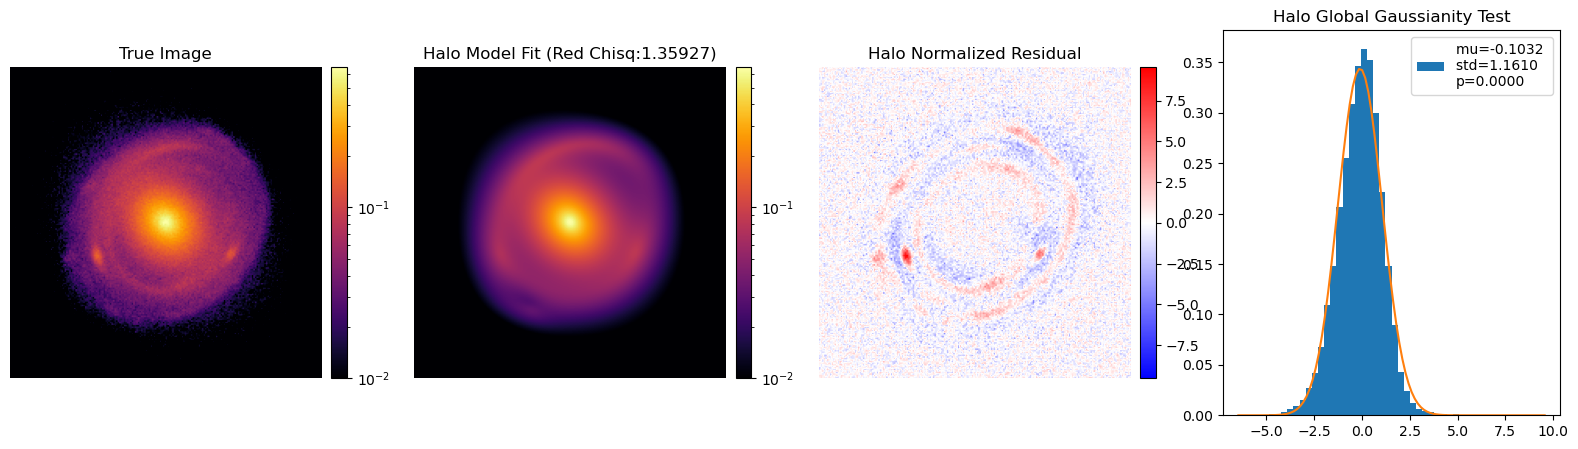

In [54]:
importlib.reload(helpers)
from helpers import *
fig, axs = plt.subplots(1,4)
fig.set_size_inches(20,5)

halo_median = jnp.median(mclmc_samples_halo, axis=(0,1))
med_x_halo = prob_model_halo.bij.forward(list(halo_median.T))

plot_image_results(fig, axs, jnp.array(observed_img), prefix="Halo", lens_sim=lens_sim_halo, predicted_params=med_x_halo, background_rms = background_rms, exp_time = exp_time)
plt.show()

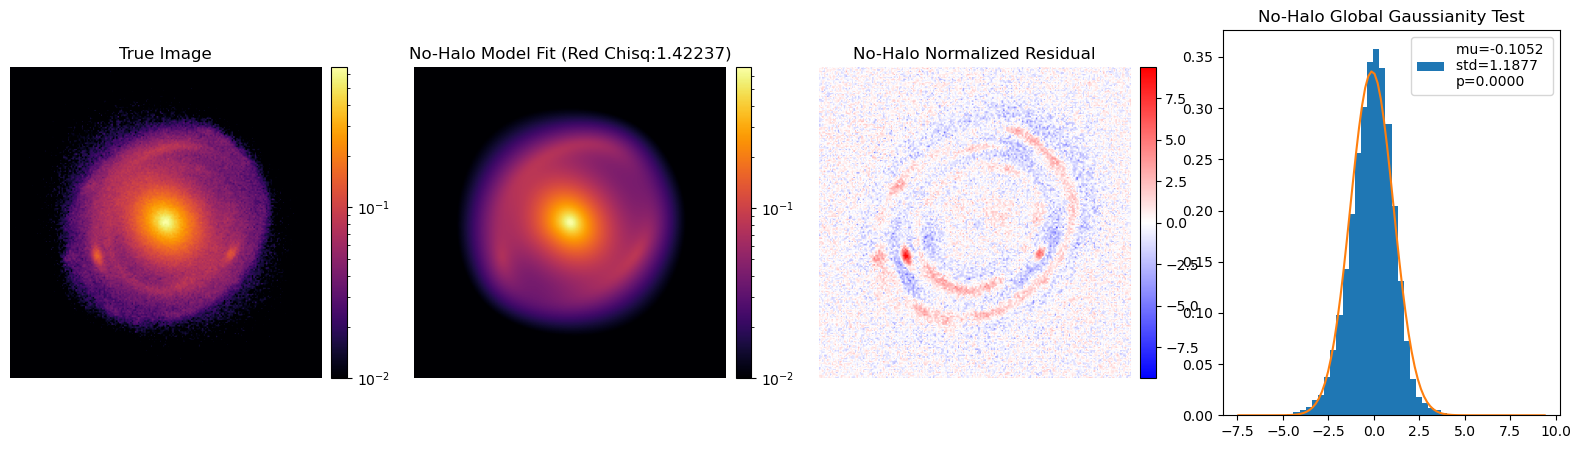

In [53]:
fig, axs = plt.subplots(1,4)
fig.set_size_inches(20,5)

no_halo_median = jnp.median(mclmc_samples_no_halo, axis=(0,1))
med_x_no_halo = prob_model_no_halo.bij.forward(list(no_halo_median.T))
plot_image_results(fig, axs, jnp.array(observed_img), prefix="No-Halo", lens_sim=lens_sim_no_halo, predicted_params=med_x_no_halo,  background_rms = background_rms, exp_time = exp_time)
plt.show()